In [1]:
!pip install kagglehub nltk -q

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

c:\Users\morro\anaconda3\envs\autotopic\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\morro\.cache\kagglehub\datasets\uciml\sms-spam-collection-dataset\versions\1


In [3]:
import sklearn
import nltk
import pandas as pd
import numpy as np
import mlflow
import matplotlib.pyplot as plt
import seaborn as sns
import re

c:\Users\morro\anaconda3\envs\autotopic\lib\site-packages\mlflow\utils\requirements_utils.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # noqa: TID251


In [4]:
df = pd.read_csv(path + '/spam.csv', encoding='latin-1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df = df.dropna(axis=1)
df = df.rename(columns={'v1': 'target', 'v2': 'text'})
df['target'] = df['target'].map({'ham': 0, 'spam': 1})

In [7]:
print(df['target'].value_counts())

target
0    4825
1     747
Name: count, dtype: int64


In [8]:
df_train, df_temp = sklearn.model_selection.train_test_split(df, stratify=df['target'], train_size=.7, random_state=42 )
df_val, df_test = sklearn.model_selection.train_test_split(df_temp, stratify=df_temp['target'], train_size=.5, random_state=42 )

In [9]:
print(len(df_train), len(df_val), len(df_test))
print(df_train['target'].value_counts(normalize=True))


3900 836 836
target
0    0.865897
1    0.134103
Name: proportion, dtype: float64


In [10]:
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\morro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\morro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [11]:
def preprocess(text: str):
    text.lower()
    text = re.sub(r'http\S+|www\S+', '[url]', text)
    text = re.sub(r'\d+', '[num]', text)
    text = re.sub(r'\$', ' [money_sign] ', text)
    text = re.sub(r'!+', ' [exclamation] ', text)

    text = re.sub(r'[^\w\s\[\]]', '', text)

    tokens = word_tokenize(text)

    allowed_tokens = {'[url]', '[money_sign]', '[exclamation]', '[number]'}
    final_tokens = [stemmer.stem(w) for w in tokens if w not in stop_words and (w.isalpha() or w in allowed_tokens)]
    
    return final_tokens

df_train['clean_text'] = df_train['text'].apply(preprocess)
print(df_train.iloc[0])

target                                                        1
text          Goal! Arsenal 4 (Henry, 7 v Liverpool 2 Henry ...
clean_text    [goal, exclam, arsen, num, henri, num, v, live...
Name: 4912, dtype: object


In [12]:
from collections import Counter

# 1. Берем только спам-сообщения
spam_words_series = df_train[df_train['target'] == 1]['clean_text']

# 2. "Взрываем" списки слов в один длинный Series и считаем частоты
spam_counts = Counter(spam_words_series.explode())

# То же самое для не-спама (ham)
ham_words_series = df_train[df_train['target'] == 0]['clean_text']
ham_counts = Counter(ham_words_series.explode())

# Посмотрим на топ-5 самых частых слов в спаме
print("Top spam words:", spam_counts.most_common(5))

Top spam words: [('num', 2244), ('exclam', 376), ('call', 266), ('å', 196), ('free', 165)]


In [13]:
# Сумма всех частот слов в спаме
total_spam_words = sum(spam_counts.values())

# Сумма всех частот слов в обычном тексте
total_ham_words = sum(ham_counts.values())

# Количество уникальных слов во всем словаре (размер словаря)
# Это понадобится для сглаживания Лапласа, чтобы не делить на ноль
vocabulary_size = len(set(list(spam_counts.keys()) + list(ham_counts.keys())))
print(vocabulary_size)

# Общее количество примеров в тренировочном наборе
n_total = len(df_train)

# Считаем количество спама (сумма единичек)
n_spam = df_train['target'].sum()

# Вероятность спама
p_spam = n_spam / n_total

# Вероятность хама (все остальное)
p_ham = 1 - p_spam

print(f"Вероятность спама: {p_spam:.4f}")
print(f"Вероятность хама: {p_ham:.4f}")

5879
Вероятность спама: 0.1341
Вероятность хама: 0.8659


In [16]:
import math

def predict_log_score(words, class_counter, total_class_words, p_class, vocab_size):

    log_score = math.log(p_class)

    for word in words:
        count = class_counter.get(word, 0)

        word_p =  (count + 1 )/ (total_class_words + vocab_size)

        log_score += math.log(word_p)

    return log_score
 

def get_predictions(df_column, threshold=0):
    preds = []
    for tokens in df_column:
        # Считаем лог-вероятности для обоих классов
        spam_s = predict_log_score(tokens, spam_counts, total_spam_words, p_spam, vocabulary_size)
        ham_s = predict_log_score(tokens, ham_counts, total_ham_words, p_ham, vocabulary_size)
        
        # Если разница больше порога — это спам
        if (spam_s - ham_s) > threshold:
            preds.append(1)
        else:
            preds.append(0)
    return np.array(preds)

# Применяем твою функцию предобработки к валидационному набору
df_val['clean_text'] = df_val['text'].apply(preprocess)
 
# Получаем предсказания для валидационной выборки
y_val_true = df_val['target'].values
y_val_pred = get_predictions(df_val['clean_text'], threshold=0)

# Считаем базовую метрику — Accuracy
accuracy = (y_val_pred == y_val_true).mean()
print(f"Validation Accuracy: {accuracy:.4f}")


Validation Accuracy: 0.9725


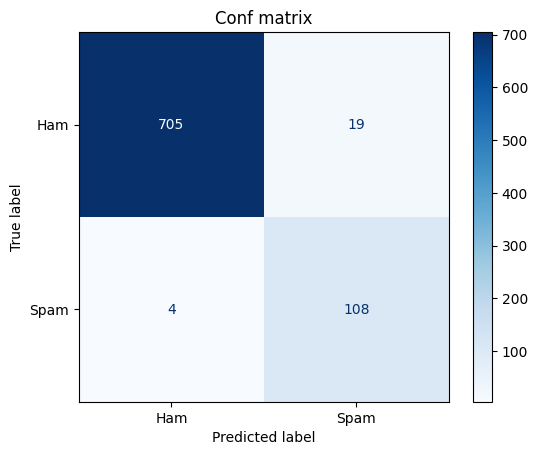

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val_true, y_val_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Conf matrix')
plt.show()

In [20]:
fp_examples = df_val[(df_val['target'] == 0) & (y_val_pred == 1)]

# Выводим первые 5 текстов, чтобы почитать их
print(fp_examples['text'].head())

2961         \NONE!NOWHERE IKNO DOESDISCOUNT!SHITINNIT\""
5213                               3 pa but not selected.
3147    \CHEERS U TEX MECAUSE U WEREBORED! YEAH OKDEN ...
2539                     Hmmm:)how many players selected?
3715              Networking technical support associate.
Name: text, dtype: object


In [22]:
ratios = {}

all_words = set(list(spam_counts.keys()) + list(ham_counts.keys()))

for word in all_words:
    # 1. Считаем P(word|Spam) с Лапласом
    p_w_spam = (spam_counts[word] + 1) / (total_spam_words + vocabulary_size)
    
    # 2. Считаем P(word|Ham) с Лапласом
    p_w_ham = (ham_counts[word] + 1) / (total_ham_words + vocabulary_size)
    
    # 3. Вычисляем Ratio
    ratios[word] = p_w_spam / p_w_ham

# Сортируем по убыванию Ratio, чтобы увидеть топ спам-триггеров
top_spam_triggers = sorted(ratios.items(), key=lambda x: x[1], reverse=True)[:10]

print(top_spam_triggers)

[('claim', 177.51360205932252), ('prize', 128.69736149300883), ('tone', 117.60276136430117), ('å', 109.28181126777042), ('award', 97.63248113262739), ('pobox', 71.005440823729), ('guarante', 66.56760077224595), ('voucher', 66.56760077224595), ('ppm', 66.56760077224595), ('nokia', 52.14462060492599)]


In [24]:
thresholds = [0, 5, 7, 10, 20, 50]

print(f"{'Threshold':<10} | {'FP (Ошибки на Ham)':<20} | {'FN (Пропуски Spam)':<20}")
print("-" * 55)

for t in thresholds:
    preds = get_predictions(df_val['clean_text'], threshold=t)
    
    # Считаем FP: реально 0, предсказано 1
    fp = ((y_val_true == 0) & (preds == 1)).sum()
    
    # Считаем FN: реально 1, предсказано 0
    fn = ((y_val_true == 1) & (preds == 0)).sum()
    
    print(f"{t:<10} | {fp:<20} | {fn:<20}")

Threshold  | FP (Ошибки на Ham)   | FN (Пропуски Spam)  
-------------------------------------------------------
0          | 19                   | 4                   
5          | 3                    | 10                  
7          | 0                    | 15                  
10         | 0                    | 20                  
20         | 0                    | 38                  
50         | 0                    | 93                  


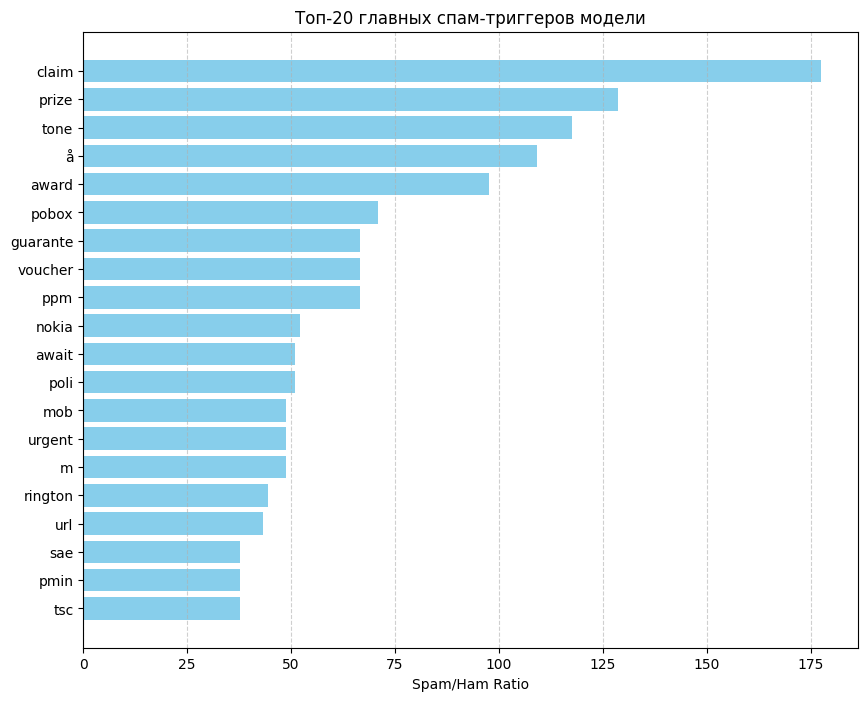

In [26]:
import matplotlib.pyplot as plt

# 1. Сортируем слова по значению Ratio и берем топ-20
top_20_ratios = sorted(ratios.items(), key=lambda x: x[1], reverse=True)[:20]

# 2. Подготавливаем данные для графика
words = [item[0] for item in top_20_ratios]
values = [item[1] for item in top_20_ratios]

# 3. Рисуем горизонтальный барчарт
plt.figure(figsize=(10, 8))
plt.barh(words[::-1], values[::-1], color='skyblue') # Разворачиваем, чтобы топ был сверху
plt.xlabel('Spam/Ham Ratio')
plt.title('Топ-20 главных спам-триггеров модели')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

In [27]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# 1. Превращаем текст в матрицу частот слов
vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(df_train['text']) # Используем оригинальный или очищенный текст
X_val = vectorizer.transform(df_val['text'])

y_train = df_train['target']
y_val = df_val['target']

# 2. Обучаем готовую модель
nb_sklearn = MultinomialNB()
nb_sklearn.fit(X_train, y_train)

# 3. Делаем предсказание
y_pred_sklearn = nb_sklearn.predict(X_val)

print(f"Accuracy (Sklearn): {accuracy_score(y_val, y_pred_sklearn):.4f}")
print(f"Accuracy (Твоя модель): {accuracy:.4f}")

Accuracy (Sklearn): 0.9809
Accuracy (Твоя модель): 0.9725


In [28]:
def classify_message(text):
    # 1. Применяем твою функцию очистки
    clean_tokens = preprocess(text)
    
    # 2. Считаем баллы (используем порог 7, который ты выбрал)
    spam_s = predict_log_score(clean_tokens, spam_counts, total_spam_words, p_spam, vocabulary_size)
    ham_s = predict_log_score(clean_tokens, ham_counts, total_ham_words, p_ham, vocabulary_size)
    
    diff = spam_s - ham_s
    
    print(f"\nТекст: {text}")
    print(f"Разница баллов: {diff:.2f}")
    
    if diff > 7:
        print("Результат: 🚩 ЭТО СПАМ")
    else:
        print("Результат: ✅ ЭТО ХАМ (нормальное письмо)")

# Запускаем проверку
classify_message("WINNER! You have won a free prize, click here to claim your cash now!")
classify_message("Hey, are we still meeting for coffee at 5?")


Текст: WINNER! You have won a free prize, click here to claim your cash now!
Разница баллов: 17.80
Результат: 🚩 ЭТО СПАМ

Текст: Hey, are we still meeting for coffee at 5?
Разница баллов: -7.20
Результат: ✅ ЭТО ХАМ (нормальное письмо)
